# Momentum Regime Analysis
## 02 - Momentum Signal Construction

We construct a cross-sectional momentum signal across 11 S&P 500 sector ETFs.

### The Signal
Each month, we rank all 11 sectors by their trailing 12-month return (excluding the most recent month). We go long the top 3 sectors and short the bottom 3. This is called a **cross-sectional momentum strategy** we're not betting on the market going up or down, we're betting on *relative* performance between sectors.

### Why exclude the most recent month?
The most recent month is excluded from the ranking window because of a well-documented phenomenon called **short-term reversal** assets that did well in the very last month tend to slightly reverse in the next month. Excluding it gives a cleaner signal.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pull data (same as notebook 01)
tickers = [
    "XLB", "XLC", "XLE", "XLF", "XLI",
    "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"
]

raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna(axis=1, how="all")
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna(how="all")

print(f"Loaded: {prices.shape[0]} days, {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

[*********************100%***********************]  11 of 11 completed

Loaded: 4117 days, 11 tickers
Date range: 2010-01-04 to 2026-05-15


In [2]:
# Resample daily prices to monthly (taking the last price of each month)
monthly_prices = prices.resample("ME").last()
print(f"Monthly prices shape: {monthly_prices.shape}")
print(monthly_prices.tail())

Monthly prices shape: (197, 11)
Ticker            XLB         XLC        XLE        XLF         XLI  \
Date                                                                  
2026-01-31  49.051861  119.698029  50.718616  53.166702  164.976440   
2026-02-28  53.173531  117.674492  55.557003  51.166985  176.643646   
2026-03-31  49.970001  110.860001  61.259998  49.369999  161.729996   
2026-04-30  51.470001  116.510002  59.650002  52.130001  174.580002   
2026-05-31  50.299999  116.080002  59.439999  51.099998  171.399994   

Ticker             XLK        XLP       XLRE        XLU         XLV  \
Date                                                                  
2026-01-31  143.701340  83.042580  41.153393  42.949722  154.106476   
2026-02-28  138.587677  89.506195  43.547302  47.398617  159.544113   
2026-03-31  132.899994  81.980003  40.830002  45.889999  146.610001   
2026-04-30  159.500000  84.309998  44.400002  46.849998  145.990005   
2026-05-31  176.259995  84.639999  43.230000

In [3]:
# Calculate trailing 12-month return for each sector, excluding the most recent month
# Shift(1) skips the most recent month, then we look back 12 months from there
# In log return terms: 12-month return = sum of 12 monthly log returns
monthly_log_returns = np.log(monthly_prices / monthly_prices.shift(1))
trailing_12m = monthly_log_returns.shift(1).rolling(window=12).sum()

print("Trailing 12-month log returns (last 5 months):")
print(trailing_12m.tail())

Trailing 12-month log returns (last 5 months):
Ticker           XLB       XLC       XLE       XLF       XLI       XLK  \
Date                                                                     
2026-01-31  0.094795  0.207652  0.075815  0.138912  0.176865  0.219986   
2026-02-28  0.123908  0.171560  0.185572  0.051383  0.192470  0.226742   
2026-03-31  0.204929  0.158229  0.239066 -0.000655  0.275510  0.213650   
2026-04-30  0.169857  0.151567  0.302448  0.006451  0.223584  0.258239   
2026-05-31  0.224042  0.211803  0.424984  0.082154  0.298895  0.423925   

Ticker           XLP      XLRE       XLU       XLV       XLY  
Date                                                          
2026-01-31  0.015048  0.025959  0.148630  0.135437  0.071118  
2026-02-28  0.082721  0.034100  0.133140  0.069635  0.051487  
2026-03-31  0.107066  0.049723  0.214643  0.090383  0.087645  
2026-04-30  0.031067  0.009503  0.179906  0.021778  0.106648  
2026-05-31  0.057135  0.106554  0.199976  0.056221  0.19

In [4]:
# Rank sectors cross-sectionally each month (rank 1 = lowest, rank 11 = highest)
# We rank across columns (axis=1) for each row (month)
ranks = trailing_12m.rank(axis=1)

print("Cross-sectional ranks (last 5 months):")
print(ranks.tail())

Cross-sectional ranks (last 5 months):
Ticker      XLB   XLC   XLE  XLF   XLI   XLK  XLP  XLRE  XLU  XLV  XLY
Date                                                                  
2026-01-31  5.0  10.0   4.0  7.0   9.0  11.0  1.0   2.0  8.0  6.0  3.0
2026-02-28  6.0   8.0   9.0  2.0  10.0  11.0  5.0   1.0  7.0  4.0  3.0
2026-03-31  7.0   6.0  10.0  1.0  11.0   8.0  5.0   2.0  9.0  4.0  3.0
2026-04-30  7.0   6.0  11.0  1.0   9.0  10.0  4.0   2.0  8.0  3.0  5.0
2026-05-31  8.0   7.0  11.0  3.0   9.0  10.0  2.0   4.0  6.0  1.0  5.0


In [5]:
# Generate signals: 1 = long, -1 = short, 0 = no position
# Top 3 ranks = long, bottom 3 ranks = short, middle 5 = no position
signals = pd.DataFrame(0, index=ranks.index, columns=ranks.columns)

signals[ranks >= 9] = 1
signals[ranks <= 3] = -1

print("Signals (last 5 months):")
print(signals.tail())
print(f"\nSignal counts per month (should always be 3 longs, 3 shorts):")
print(f"Longs: {(signals == 1).sum(axis=1).tail()}")
print(f"Shorts: {(signals == -1).sum(axis=1).tail()}")

Signals (last 5 months):
Ticker      XLB  XLC  XLE  XLF  XLI  XLK  XLP  XLRE  XLU  XLV  XLY
Date                                                              
2026-01-31    0    1    0    0    1    1   -1    -1    0    0   -1
2026-02-28    0    0    1   -1    1    1    0    -1    0    0   -1
2026-03-31    0    0    1   -1    1    0    0    -1    1    0   -1
2026-04-30    0    0    1   -1    1    1    0    -1    0   -1    0
2026-05-31    0    0    1   -1    1    1   -1     0    0   -1    0

Signal counts per month (should always be 3 longs, 3 shorts):
Longs: Date
2026-01-31    3
2026-02-28    3
2026-03-31    3
2026-04-30    3
2026-05-31    3
Freq: ME, dtype: int64
Shorts: Date
2026-01-31    3
2026-02-28    3
2026-03-31    3
2026-04-30    3
2026-05-31    3
Freq: ME, dtype: int64


In [6]:
# Strategy return each month = average return of longs minus average return of shorts
next_month_returns = monthly_log_returns.shift(-1)

strategy_returns = pd.Series(index=signals.index, dtype=float)

for date in signals.index:
    long_return = next_month_returns.loc[date, signals.loc[date] == 1].mean()
    short_return = next_month_returns.loc[date, signals.loc[date] == -1].mean()
    strategy_returns[date] = long_return - short_return

strategy_returns = strategy_returns.dropna()

print(f"Strategy returns calculated: {len(strategy_returns)} months")
print(f"\nSample:")
print(strategy_returns.tail(10))

Strategy returns calculated: 183 months

Sample:
Date
2025-07-31   -0.029230
2025-08-31    0.038762
2025-09-30    0.023854
2025-10-31   -0.076657
2025-11-30    0.019303
2025-12-31   -0.069890
2026-01-31   -0.026743
2026-02-28    0.045198
2026-03-31   -0.050059
2026-04-30    0.043594
Freq: ME, dtype: float64


In [7]:
# Annualized performance metrics
trading_months = 12

mean_return = strategy_returns.mean() * trading_months
volatility = strategy_returns.std() * np.sqrt(trading_months)
sharpe = mean_return / volatility

cumulative = strategy_returns.cumsum()
rolling_max = cumulative.cummax()
drawdown = cumulative - rolling_max
max_drawdown = drawdown.min()

print("=" * 40)
print("STRATEGY PERFORMANCE SUMMARY")
print("=" * 40)
print(f"Annualized Return:   {mean_return:.2%}")
print(f"Annualized Vol:      {volatility:.2%}")
print(f"Sharpe Ratio:        {sharpe:.2f}")
print(f"Max Drawdown:        {max_drawdown:.2%}")
print(f"Period:              {strategy_returns.index[0].date()} to {strategy_returns.index[-1].date()}")

STRATEGY PERFORMANCE SUMMARY
Annualized Return:   -3.81%
Annualized Vol:      14.59%
Sharpe Ratio:        -0.26
Max Drawdown:        -76.42%
Period:              2011-02-28 to 2026-04-30


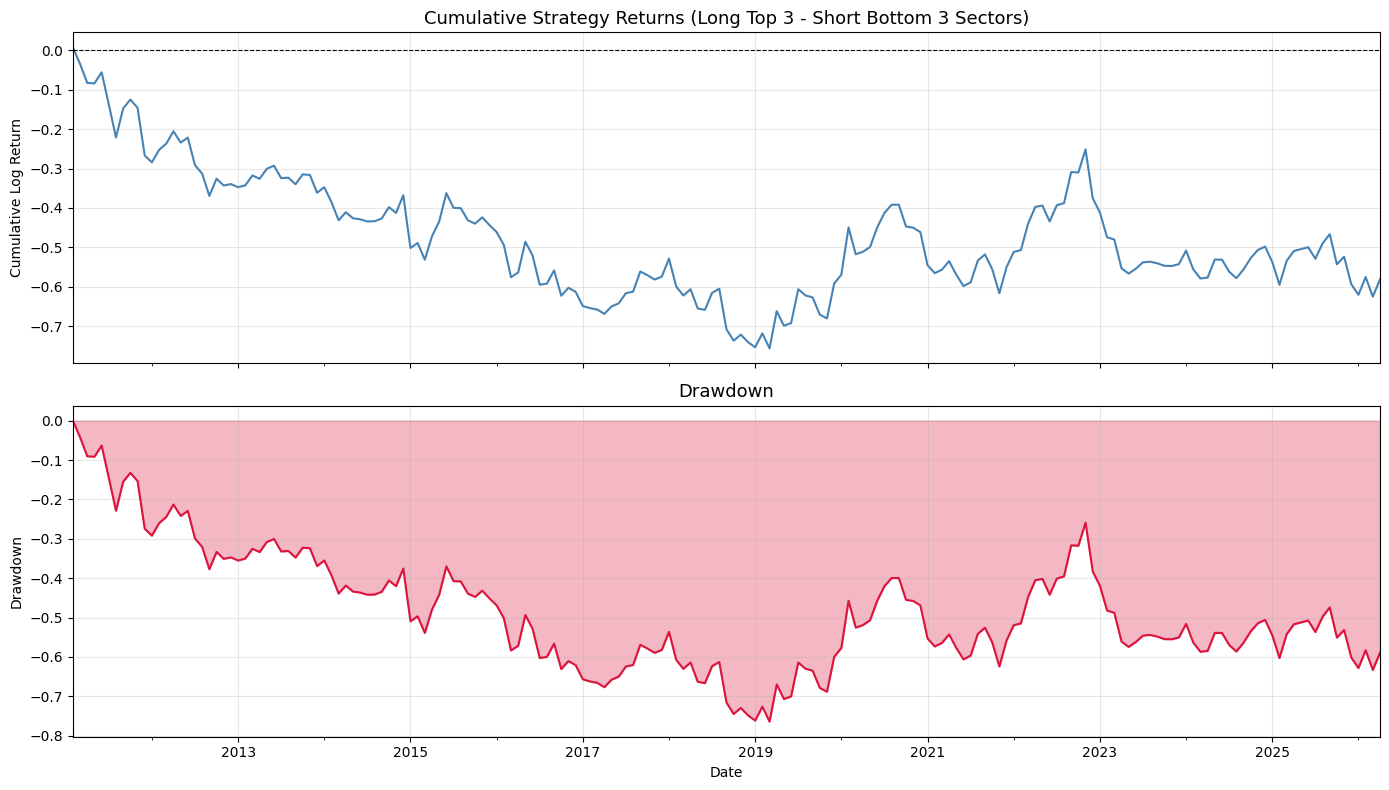

In [8]:
#Display Cumulative Returns and Drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

cumulative.plot(ax=ax1, color="steelblue", linewidth=1.5)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Cumulative Strategy Returns (Long Top 3 - Short Bottom 3 Sectors)", fontsize=13)
ax1.set_ylabel("Cumulative Log Return")
ax1.grid(alpha=0.3)

drawdown.plot(ax=ax2, color="crimson", linewidth=1.5)
ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.3, color="crimson")
ax2.set_title("Drawdown", fontsize=13)
ax2.set_ylabel("Drawdown")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


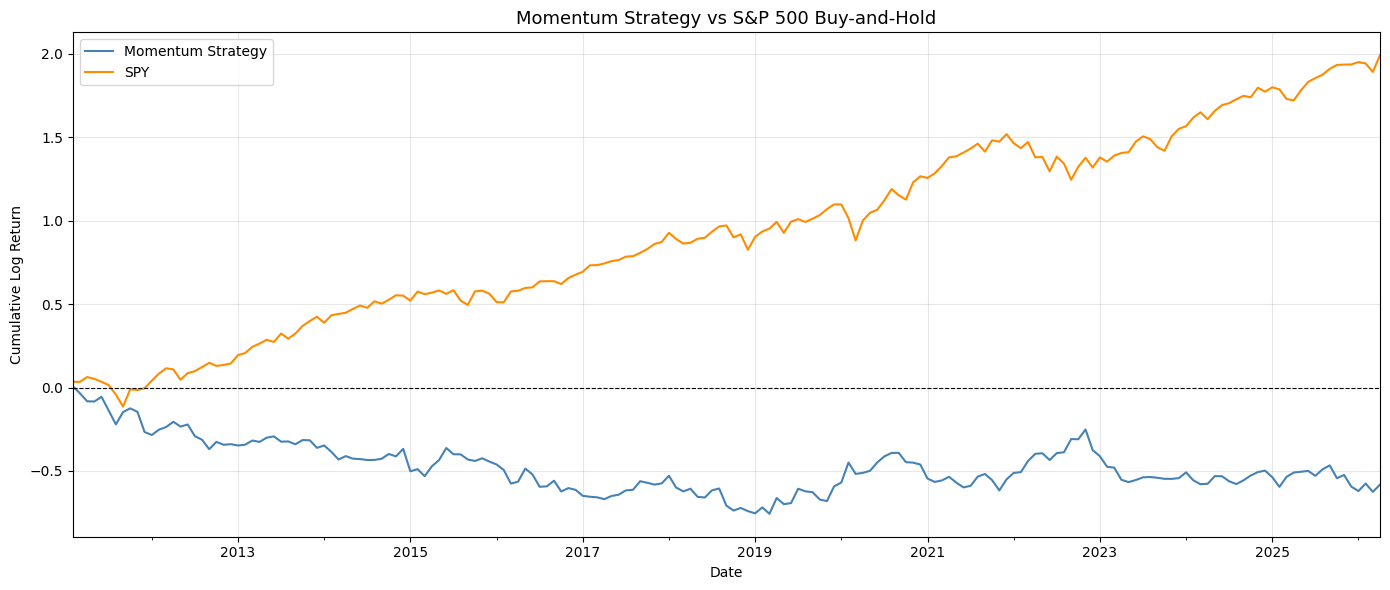

In [9]:
#Display Strategy vs S&P 500 Buy-and-Hold
spy = yf.download("SPY", start="2010-01-01", auto_adjust=True)["Close"]
spy_monthly = spy.resample("ME").last()
spy_returns = np.log(spy_monthly / spy_monthly.shift(1))
spy_returns = spy_returns.dropna()
spy_returns = spy_returns.reindex(strategy_returns.index)

fig, ax = plt.subplots(figsize=(14, 6))

strategy_returns.cumsum().plot(ax=ax, label="Momentum Strategy", color="steelblue", linewidth=1.5)
spy_returns.cumsum().plot(ax=ax, label="S&P 500 (SPY)", color="darkorange", linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Momentum Strategy vs S&P 500 Buy-and-Hold", fontsize=13)
ax.set_ylabel("Cumulative Log Return")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()